In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


In [2]:
df = pd.read_csv("../data/processed/campaign_data_cleaned.csv")
df.head()


,campaign_id,campaign_type,target_audience,duration,channel_used,impressions,clicks,leads,conversions,revenue,acquisition_cost,roi,language,engagement_score,customer_segment,date,CTR,Conversion_Rate,CPL,CPCV
0,NY-CMP-1000,Social Media,College Students,21,"WhatsApp, YouTube",57804,6156,3616,2355,1867515,111.03,6.14,Hindi,20.98,College Students,2025-04-29,0.106498,0.382554,0.030705,0.047146
1,NY-CMP-1001,Paid Ads,Tier 2 City Customers,18,YouTube,91801,3321,1971,1357,1046247,180.83,3.26,Hindi,7.24,College Students,2025-04-06,0.036176,0.408612,0.091745,0.133257
2,NY-CMP-1002,Influencer,Youth,23,"WhatsApp, Google, YouTube",15536,2182,952,755,197055,90.60,1.88,English,25.03,College Students,2025-01-14,0.140448,0.346013,0.095168,0.120000
3,NY-CMP-1003,Email,Working Women,18,"YouTube, Facebook, Instagram",88114,8413,2231,947,376906,249.07,0.60,Hindi,13.15,College Students,2025-06-04,0.095479,0.112564,0.111641,0.263010
4,NY-CMP-1004,Paid Ads,College Students,10,"Facebook, Instagram",96871,3743,2060,1258,518296,228.60,0.80,Hindi,7.29,Tier 2 City Customers,2024-12-29,0.038639,0.336094,0.110971,0.181717


In [4]:
df["date"] = pd.to_datetime(df["date"])


Define RFM logic
For marketing campaigns:

Recency → How recently a customer engaged

Frequency → How often they engaged

Monetary → Revenue generated

In [8]:
rfm = df.groupby("customer_segment").agg({
    "date": lambda x: (df["date"].max() - x.max()).days,
    "campaign_id": "count",
    "revenue": "sum"
}).reset_index()


In [9]:
rfm.columns = ["Customer_Segment", "Recency", "Frequency", "Monetary"]
rfm.head()


,Customer_Segment,Recency,Frequency,Monetary
0,College Students,0,33533,17243247161
1,Premium Shoppers,0,33071,16893770924
2,Tier 2 City Customers,0,33091,17072782747
3,Working Women,0,33413,17215043588
4,Youth,0,33557,17225401651


RFM Scoring

In [12]:
rfm["F_Score"] = pd.qcut(rfm["Frequency"], 5, labels=[1,2,3,4,5]).astype(int)
rfm["M_Score"] = pd.qcut(rfm["Monetary"], 5, labels=[1,2,3,4,5]).astype(int)


In [13]:
rfm["R_Score"] = 3   # neutral score


In [14]:
rfm["RFM_Score"] = rfm["R_Score"] + rfm["F_Score"] + rfm["M_Score"]


RFM Segmentation Rules

In [15]:
def segment(score):
    if score >= 11:
        return "High Value"
    elif score >= 8:
        return "Medium Value"
    else:
        return "Low Value"

rfm["Segment"] = rfm["RFM_Score"].apply(segment)


Visualizations

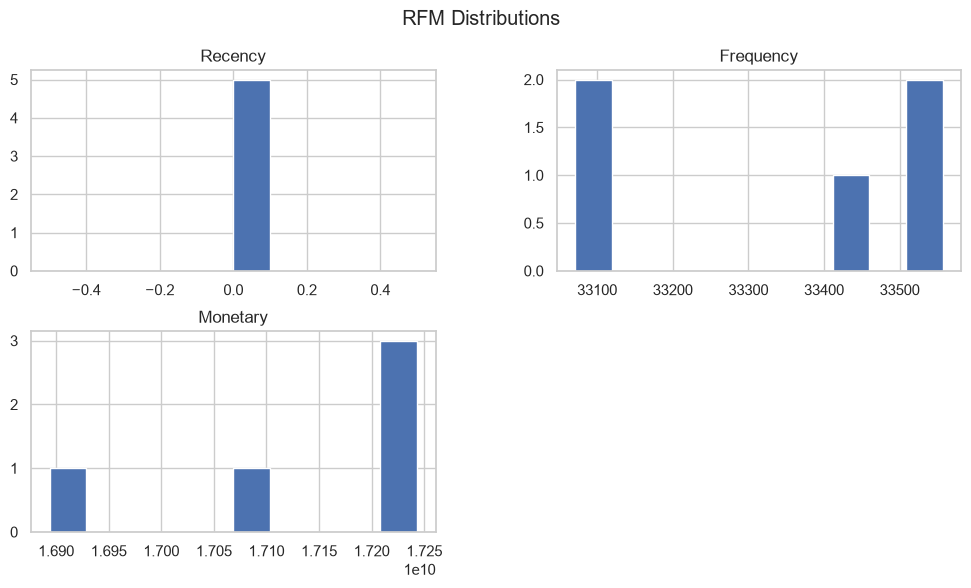

In [17]:
#1. RFM Distribution
rfm[["Recency", "Frequency", "Monetary"]].hist(figsize=(12,6))
plt.suptitle("RFM Distributions")
plt.show()


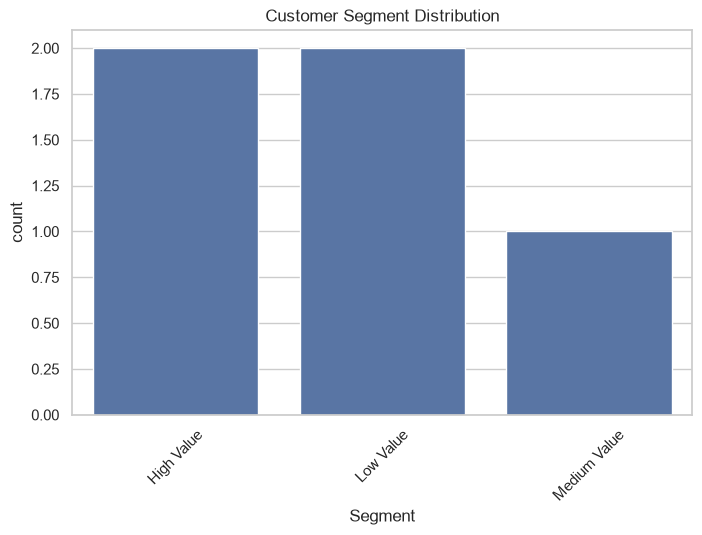

In [18]:
#2. Segment Counts
plt.figure(figsize=(8,5))
sns.countplot(data=rfm, x="Segment", order=rfm["Segment"].value_counts().index)
plt.title("Customer Segment Distribution")
plt.xticks(rotation=45)
plt.show()


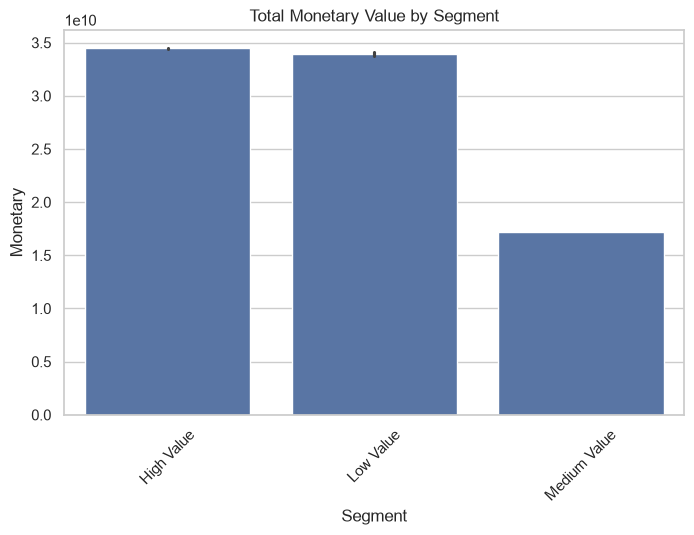

In [19]:
#3. Monetary by Segment
plt.figure(figsize=(8,5))
sns.barplot(data=rfm, x="Segment", y="Monetary", estimator=sum)
plt.title("Total Monetary Value by Segment")
plt.xticks(rotation=45)
plt.show()


In [21]:
#Export RFM Table
rfm.to_csv("../data/processed/rfm_segments.csv", index=False)
